In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from datetime import date

from aquacrop import AquaCrop, Crop, Soil, Weather, InitialConditions
from aquacrop.templates import manuloa_co2_records

from aquacrop_slovenia import config
from aquacrop_slovenia.prepare_weather import load_station_weather
from aquacrop_slovenia.crop_maize_defaults import maize_params
from aquacrop_slovenia.soil_jablje_defaults import jablje_soil_layers,jablje_curve_number,jablje_readily_evaporable_water
from aquacrop_slovenia.management_defaults import optimal_management
from aquacrop_slovenia.intial_conditions_defaults import intial_cond_params

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.MODELS_DIR / "testing"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [22]:
#year = 1993
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 5), # TODO temporary
        "planting_date": date(year, 5, 3), # TODO temporary
        "is_seeding_year": True,
    }
#]
for year in range(1993, 2024) if year != 2017]

In [23]:
jablje_temperatures, jablje_eto, jablje_rain = load_station_weather(8)

In [24]:
jablje_weather = Weather(
    location="Jablje",
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=manuloa_co2_records
)

In [25]:
jablje_maize = Crop(
    name="Jablje Maize",
    description="Jablje maize uncalibrated",
    params=maize_params
)

In [26]:
jablje_soil = Soil(
    name="Jablje Soil",
    description="Jablje silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [27]:
default_initial_conditions = InitialConditions(
    name="DefaultInitialConditions",
    description="Default initial conditions with AquaCrop calculated defaults",
    params=intial_cond_params
)

In [28]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=optimal_management,
    initial_conditions=default_initial_conditions,
    climate=jablje_weather,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [29]:
# Run the simulation
results = simulation.run()

Setting up working directory at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing
Running AquaCrop simulation with project file: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [30]:
results["season"]

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,681.9,716.9,1430.4,357.21,0.0,606.5,...,4.7,1.180,1.311,0.32,0.0,0.0,5,10,1993,PROJECT.PRM
1,2,1,1,1994,1018.2,700.2,1567.8,358.96,0.0,908.7,...,4.8,1.371,1.524,0.30,0.0,0.0,5,10,1994,PROJECT.PRM
2,3,1,1,1995,1199.5,639.2,1297.4,360.97,0.0,990.2,...,3.9,0.888,0.986,0.24,0.0,0.0,5,10,1995,PROJECT.PRM
3,4,1,1,1996,1046.5,599.3,1301.8,362.74,0.0,863.5,...,3.8,0.893,0.992,0.26,0.0,0.0,5,10,1996,PROJECT.PRM
4,5,1,1,1997,737.7,675.9,1397.7,363.88,0.0,682.0,...,4.3,1.179,1.310,0.29,0.0,0.0,5,10,1997,PROJECT.PRM
5,6,1,1,1998,963.6,667.0,1519.4,366.84,0.0,838.7,...,5.3,1.433,1.592,0.39,0.0,0.0,5,10,1998,PROJECT.PRM
6,7,1,1,1999,1088.3,634.7,1551.9,368.54,0.0,937.1,...,5.5,1.654,1.837,0.38,0.0,0.0,5,10,1999,PROJECT.PRM
7,8,1,1,2000,818.5,700.3,1527.1,369.71,0.0,740.1,...,4.8,1.328,1.476,0.31,0.0,0.0,5,10,2000,PROJECT.PRM
8,9,1,1,2001,1045.5,654.6,1453.8,371.32,0.0,884.7,...,4.9,1.272,1.413,0.31,0.0,0.0,5,10,2001,PROJECT.PRM
9,10,1,1,2002,861.9,638.0,1484.6,373.45,0.0,779.3,...,5.6,1.553,1.725,0.38,0.0,0.0,5,10,2002,PROJECT.PRM


<Axes: xlabel='Year1'>

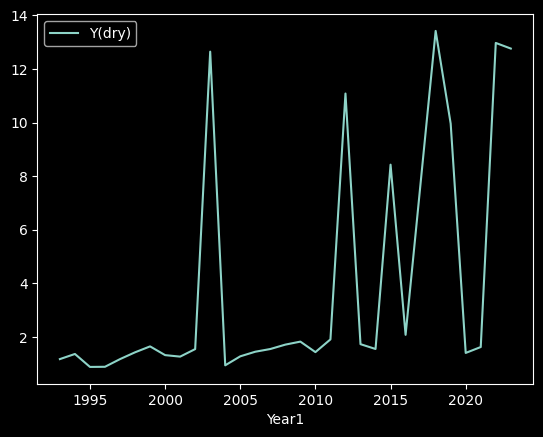

In [31]:
results["season"].plot(x="Year1", y="Y(dry)")

In [32]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,758.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,758.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,757.4,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,757.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,756.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,1,10,1993,152,4,773.7,0.6,0.0,0.0,0.6,...,None,None,None,None,None,None,None,None,None,None
274,2,10,1993,153,4,770.8,5.7,0.0,0.0,5.6,...,None,None,None,None,None,None,None,None,None,None
275,3,10,1993,154,4,787.7,33.7,0.0,0.0,22.7,...,None,None,None,None,None,None,None,None,None,None
276,4,10,1993,155,4,776.4,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

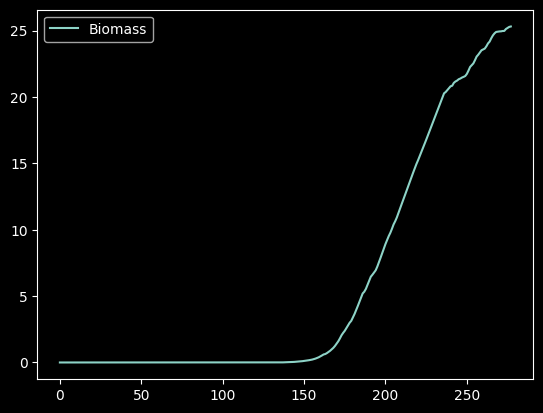

In [33]:
results["day"].plot(y="Biomass")

<Axes: >

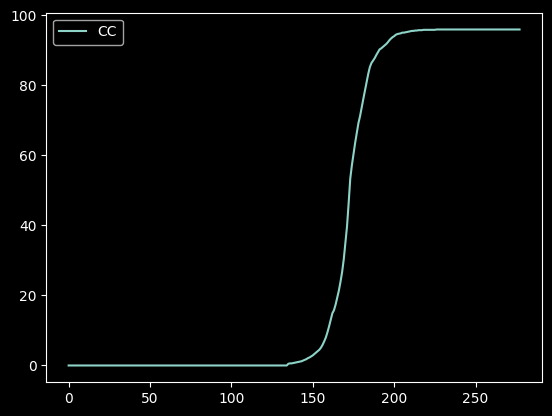

In [34]:
results["day"].plot(y="CC")

<Axes: >

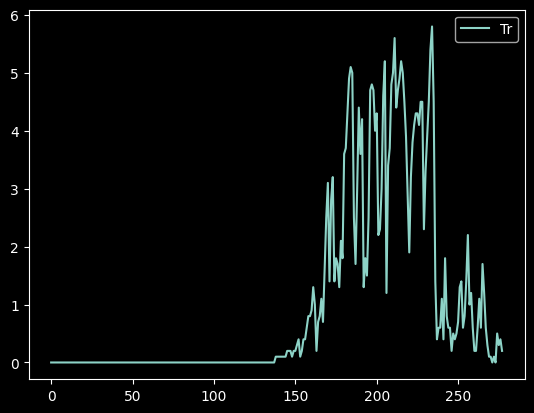

In [35]:
results["day"].plot(y="Tr")

<Axes: >

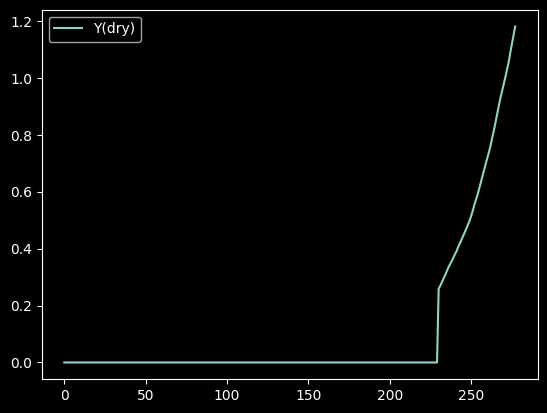

In [36]:
results["day"].plot(y="Y(dry)")

In [ ]:
from aquacrop_slovenia.gdd import a as calc_gdd

base_temp = maize_params['base_temp']
upper_temp = maize_params['upper_temp']

temps_1993 = jablje_temperatures[:365]
gdd_1993 = sum(calc_gdd(tmax, tmin, base_temp, upper_temp) for tmin, tmax in temps_1993)
print(f"Total GDD for 1993: {gdd_1993:.1f}")